In [2]:
!pip install -q datasets

import torch
import torch.nn.functional as F
from datasets import load_dataset

ds = load_dataset("codesignal/wine-quality", split="red")
data = ds.to_pandas()
print(f"Shape: {data.shape}")
data.head()

Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
X = torch.tensor(data.drop(columns=["quality"]).values, dtype=torch.float32)
y = torch.tensor(data["quality"].values, dtype=torch.float32)

# Normalize
X = (X - X.mean(dim=0)) / X.std(dim=0)

# Split 80/20
n = int(0.8 * len(X))
Xtr, Xte = X[:n], X[n:]
ytr, yte = y[:n], y[n:]

print(f"Train: {Xtr.shape}, Test: {Xte.shape}")

Train: torch.Size([1279, 11]), Test: torch.Size([320, 11])


In [4]:
torch.manual_seed(42)

# 11 inputs -> 64 -> 32 -> 1 output
W1 = torch.randn(11, 64) * 0.1; b1 = torch.zeros(64)
W2 = torch.randn(64, 32) * 0.1; b2 = torch.zeros(32)
W3 = torch.randn(32, 1) * 0.1;  b3 = torch.zeros(1)

params = [W1, b1, W2, b2, W3, b3]
for p in params:
    p.requires_grad = True

losses = []
for epoch in range(1000):
    h1 = torch.tanh(Xtr @ W1 + b1)
    h2 = torch.tanh(h1 @ W2 + b2)
    pred = (h2 @ W3 + b3).squeeze()
    loss = F.mse_loss(pred, ytr)

    loss.backward()

    lr = 0.01 if epoch < 500 else 0.001
    with torch.no_grad():
        for p in params:
            p -= lr * p.grad
            p.grad.zero_()

    losses.append(loss.item())
    if epoch % 200 == 0:
        print(f"epoch {epoch:4d} | loss {loss.item():.4f}")

epoch    0 | loss 32.6882
epoch  200 | loss 0.4147
epoch  400 | loss 0.4066
epoch  600 | loss 0.4029
epoch  800 | loss 0.4023


In [5]:
with torch.no_grad():
    h1 = torch.tanh(Xte @ W1 + b1)
    h2 = torch.tanh(h1 @ W2 + b2)
    pred = (h2 @ W3 + b3).squeeze()
    test_loss = F.mse_loss(pred, yte)
    within_1 = ((pred - yte).abs() <= 1.0).float().mean()

print(f"Test MSE: {test_loss.item():.4f}")
print(f"Within ±1 of actual: {within_1.item()*100:.1f}%")

Test MSE: 0.4103
Within ±1 of actual: 89.1%


Matplotlib is building the font cache; this may take a moment.


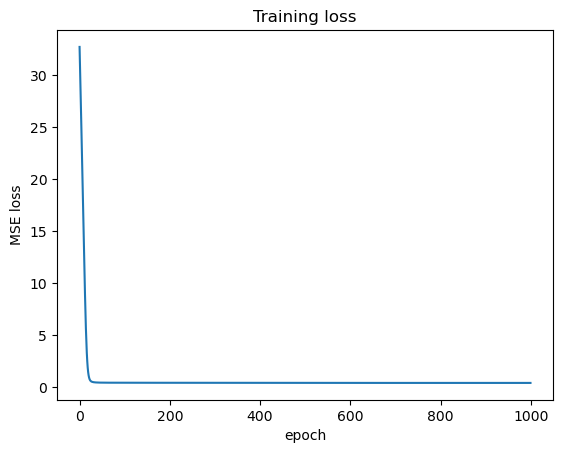

In [6]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.title("Training loss")
plt.show()